### Install packages and prepare dataset

In [1]:
!pip install tensorflow==2.16.1 keras==3.0.5


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import os
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "dataset_2D/Training"
test_dir = "dataset_2D/Testing"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2870 files belonging to 4 classes.
Found 394 files belonging to 4 classes.


In [3]:
class_names = train_dataset.class_names
print(class_names)
def convert_to_binary(images, labels):
    
    no_tumor_index = class_names.index('no_tumor')
    
    binary_labels = tf.where(labels == no_tumor_index, 0, 1)
    return images, binary_labels

train_dataset = train_dataset.map(convert_to_binary)
test_dataset = test_dataset.map(convert_to_binary)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [4]:
val_size = 0.2

train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = int(val_size * train_batches)

val_dataset = train_dataset.take(val_batches)
train_dataset = train_dataset.skip(val_batches)

### Tune the system, define and train the model

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
for imgs, labels in train_dataset.take(1):
    print("Label dtype:", labels.dtype)
    print("Label min:", tf.reduce_min(labels))
    print("Label max:", tf.reduce_max(labels))
    print("Unique:", tf.unique(tf.reshape(labels, [-1]))[0])

Label dtype: <dtype: 'int32'>
Label min: tf.Tensor(0, shape=(), dtype=int32)
Label max: tf.Tensor(1, shape=(), dtype=int32)
Unique: tf.Tensor([1 0], shape=(2,), dtype=int32)


In [7]:
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(base_model.input, outputs=output)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 495s 6s/step - accuracy: 0.8388 - loss: 0.3670 - val_accuracy: 0.9688 - val_loss: 0.1098
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 483s 7s/step - accuracy: 0.9872 - loss: 0.0517 - val_accuracy: 0.9774 - val_loss: 0.0569
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 474s 7s/step - accuracy: 0.9966 - loss: 0.0218 - val_accuracy: 0.9861 - val_loss: 0.0460
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1553s 22s/step - accuracy: 0.9982 - loss: 0.0111 - val_accuracy: 0.9844 - val_loss: 0.0426
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 464s 6s/step - accuracy: 0.9997 - loss: 0.0056 - val_accuracy: 0.9826 - val_loss: 0.0487
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 505s 7s/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9861 - val_loss: 0.0479
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 517s 7s/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9826 - val_loss: 0.0487
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 721s 10s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9844 

### Evaluate the model for different metrics

In [10]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8362 - loss: 0.9603
Test Accuracy: 0.9061


In [11]:
model.save("MRI_DenseNet.keras")

In [12]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model.predict(images)
    
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities → binary predictions
y_pred = (y_pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Tumor"]))

Confusion Matrix:
 [[103   2]
 [ 35 254]]

Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.75      0.98      0.85       105
       Tumor       0.99      0.88      0.93       289

    accuracy                           0.91       394
   macro avg       0.87      0.93      0.89       394
weighted avg       0.93      0.91      0.91       394



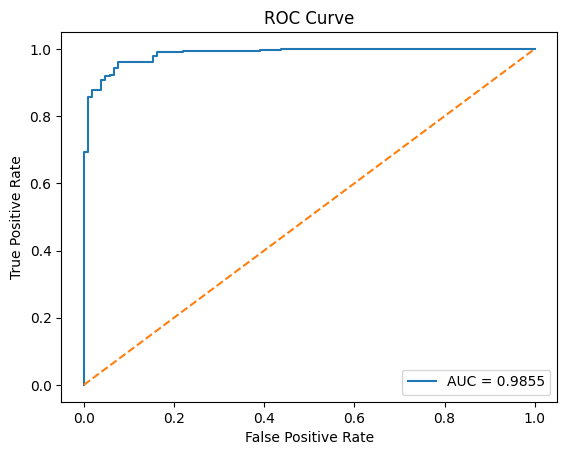

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

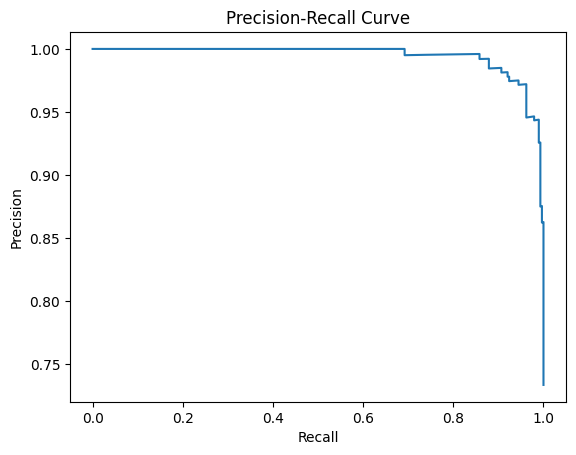

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

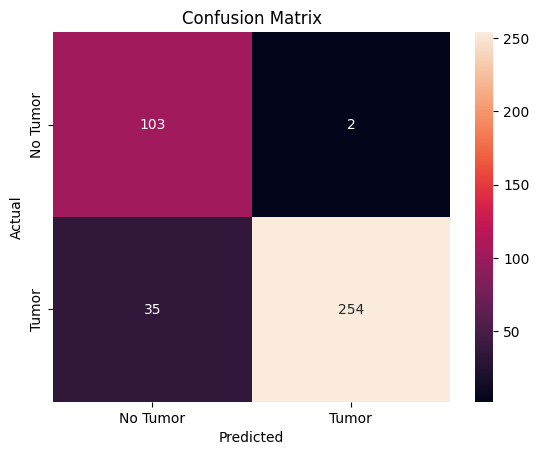

In [16]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Applying XAI methods

In [17]:
import methods as M
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os

In [18]:
root_dir = "BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData"

patients = sorted(os.listdir(root_dir))[:3]

data = [M.get_central_slice(os.path.join(root_dir, p)) for p in patients]

# ONLY FIRST PATIENT
img, gt = data[0]

In [19]:
last_conv_layer = "conv5_block16_concat"

In [20]:
def preprocess_eff(img):
    x = np.expand_dims(img, axis=0)
    return tf.keras.applications.densenet.preprocess_input(x)

In [21]:
img_batch = preprocess_eff(img)

In [22]:
hm_gradcam = M.make_gradcam_heatmap(
    img_batch, model, last_conv_layer
)

hm_gcpp = M.gradcam_plus_plus(
    img_batch, model, last_conv_layer
)

hm_ig = M.integrated_gradients(
    model, img_batch
)

hm_sg = M.smoothgrad(
    model, img_batch
)

In [23]:
methods = {
    "GradCAM": M.prepare_heatmap(hm_gradcam),
    "GradCAM++": M.prepare_heatmap(hm_gcpp),
    "Integrated Gradients": M.prepare_heatmap(hm_ig),
    "SmoothGrad": M.prepare_heatmap(hm_sg),
}

In [24]:
overlays = {
    name: M.overlay_heatmap(img, hm)
    for name, hm in methods.items()
}

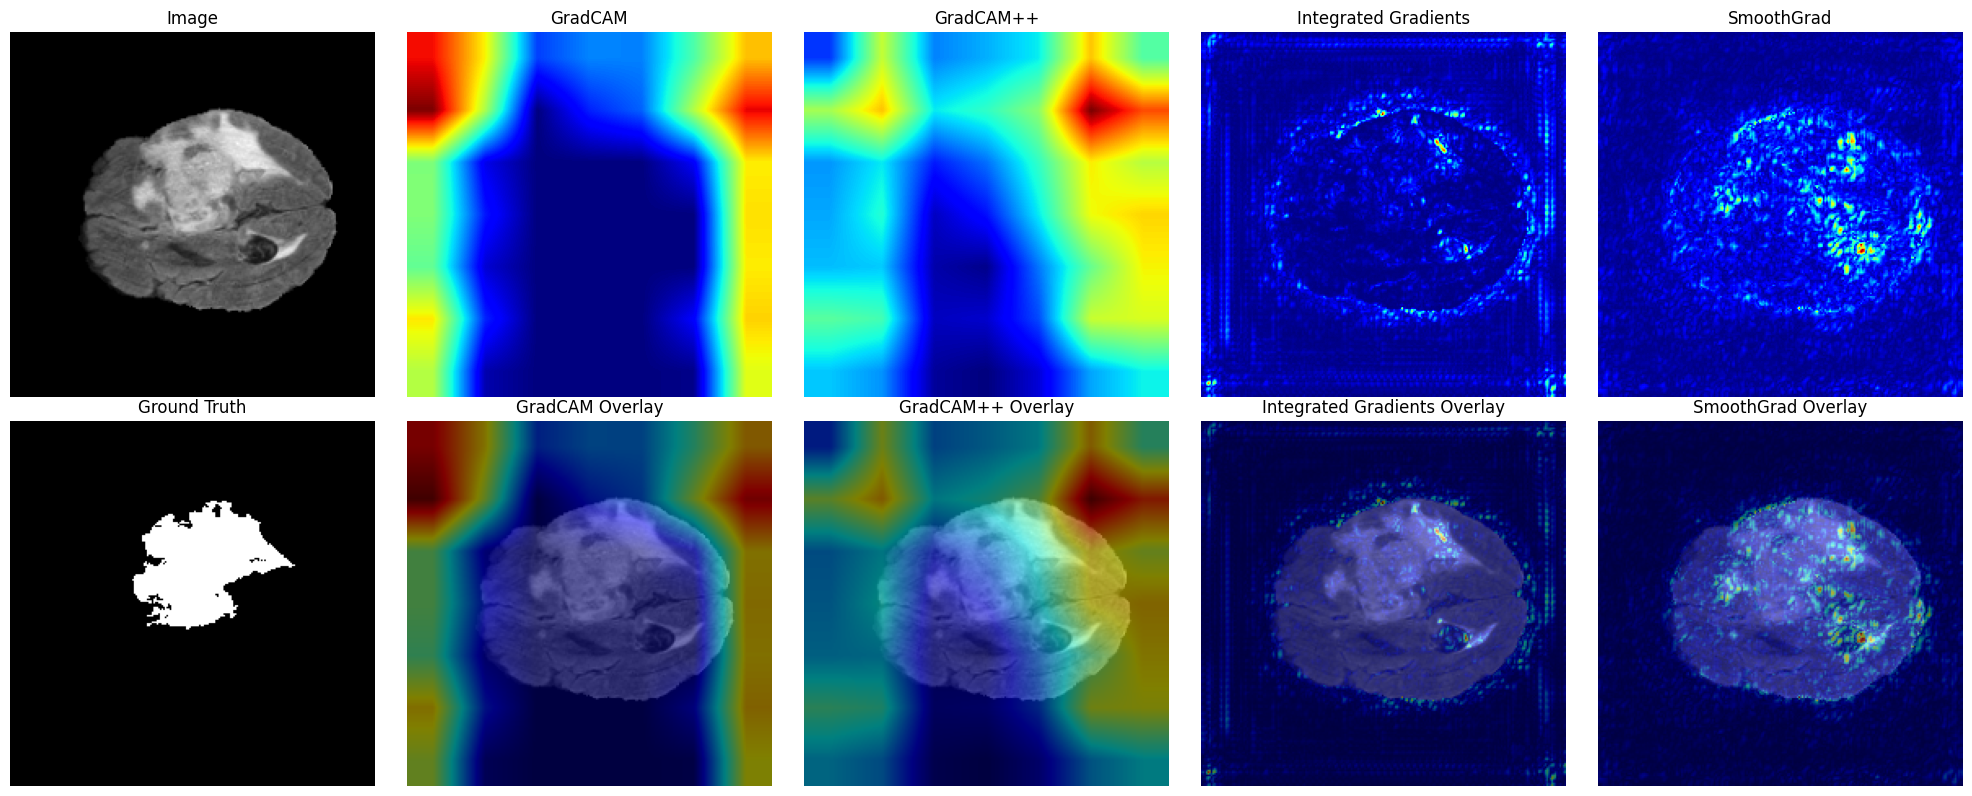

In [25]:
plt.figure(figsize=(20,8))



plt.subplot(2,5,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

titles = ["GradCAM", "GradCAM++", "Integrated Gradients", "SmoothGrad"]

for i, t in enumerate(titles):
    plt.subplot(2,5,i+2)
    plt.imshow(methods[t], cmap="jet")
    plt.title(t)
    plt.axis("off")



plt.subplot(2,5,6)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

for i, t in enumerate(titles):
    plt.subplot(2,5,i+7)
    plt.imshow(overlays[t])
    plt.title(f"{t} Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd

results = []

for idx, (img, gt) in enumerate(data):

    img_batch = preprocess_eff(img)

    # ---- Heatmaps ----
    hm_gradcam = M.make_gradcam_heatmap(img_batch, model, last_conv_layer)
    hm_gcpp    = M.gradcam_plus_plus(img_batch, model, last_conv_layer)
    hm_ig      = M.integrated_gradients(model, img_batch)
    hm_sg      = M.smoothgrad(model, img_batch)

    methods = {
        "GradCAM": M.prepare_heatmap(hm_gradcam),
        "GradCAM++": M.prepare_heatmap(hm_gcpp),
        "IG": M.prepare_heatmap(hm_ig),
        "SmoothGrad": M.prepare_heatmap(hm_sg),
    }

    # ---- Metrics ----
    for name, hm in methods.items():

        pred_mask = M.heatmap_to_mask(hm)

        dice = M.dice_score(gt, pred_mask)
        iou  = M.iou_score(gt, pred_mask)

        results.append({
            "Patient": idx+1,
            "Method": name,
            "Dice": dice,
            "IoU": iou
        })

In [27]:
df = pd.DataFrame(results)

df

,Patient,Method,Dice,IoU
0,1,GradCAM,0.000000,0.000000
1,1,GradCAM++,0.071717,0.037192
2,1,IG,0.016540,0.008339
3,1,SmoothGrad,0.033635,0.017105
4,2,GradCAM,0.000000,0.000000
5,2,GradCAM++,0.000000,0.000000
6,2,IG,0.000000,0.000000
7,2,SmoothGrad,0.172148,0.094180
8,3,GradCAM,0.000000,0.000000
9,3,GradCAM++,0.035695,0.018172


In [28]:
avg_df = df.groupby("Method")[["Dice","IoU"]].mean()
print("\nAverage Performance:\n")
avg_df


Average Performance:



,Dice,IoU
Method,,
GradCAM,0.000000,0.000000
GradCAM++,0.035804,0.018455
IG,0.010526,0.005305
SmoothGrad,0.068594,0.037095


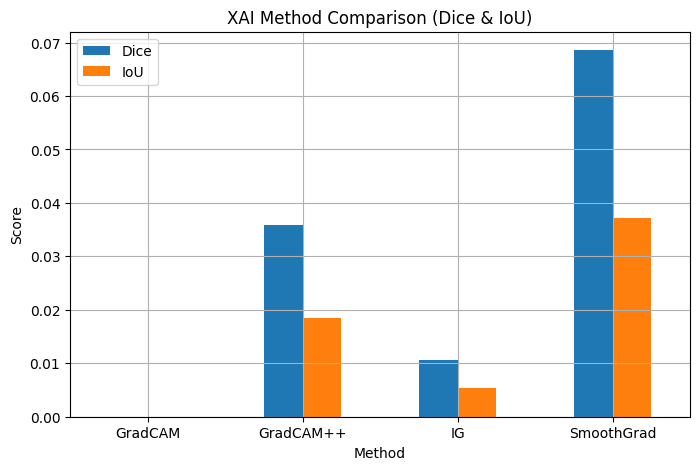

In [29]:
import matplotlib.pyplot as plt

avg_df.plot(kind="bar", figsize=(8,5))
plt.title("XAI Method Comparison (Dice & IoU)")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.grid()
plt.show()

### Faithfulness tests and comparison

In [30]:
import importlib
importlib.reload(M)
help(M.evaluate_setting)

Help on function evaluate_setting in module methods:

evaluate_setting(model, img, methods, del_fn, ins_fn, preprocess_fn, name)



In [31]:
import methods as M

In [32]:
preprocess = tf.keras.applications.densenet.preprocess_input

In [33]:
df_black = M.evaluate_setting(model, img, methods, M.deletion_pixel_black, M.insertion_pixel_black, preprocess, "Pixel Blackout")
df_black


Pixel Blackout Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.506973       0.514271
1   GradCAM++      0.526856       0.586463
2          IG      0.181930       0.359242
3  SmoothGrad      0.150742       0.446417


,Method,Deletion_AUC,Insertion_AUC
0,GradCAM,0.506973,0.514271
1,GradCAM++,0.526856,0.586463
2,IG,0.181930,0.359242
3,SmoothGrad,0.150742,0.446417


In [34]:
df_blur = M.evaluate_setting(model, img, methods, M.deletion_pixel_blur, M.insertion_pixel_blur, preprocess, "Pixel Blur")
df_blur


Pixel Blur Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.381193       0.501967
1   GradCAM++      0.388702       0.630129
2          IG      0.203687       0.311916
3  SmoothGrad      0.175657       0.263785


,Method,Deletion_AUC,Insertion_AUC
0,GradCAM,0.381193,0.501967
1,GradCAM++,0.388702,0.630129
2,IG,0.203687,0.311916
3,SmoothGrad,0.175657,0.263785


In [35]:
df_region = M.evaluate_setting(model, img, methods, M.deletion_region_blur, M.insertion_region_blur, preprocess, "Region blur")
df_region


Region blur Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.399672       0.523510
1   GradCAM++      0.380635       0.622961
2          IG      0.414805       0.443382
3  SmoothGrad      0.321351       0.400271


,Method,Deletion_AUC,Insertion_AUC
0,GradCAM,0.399672,0.523510
1,GradCAM++,0.380635,0.622961
2,IG,0.414805,0.443382
3,SmoothGrad,0.321351,0.400271


In [36]:
final_df = pd.concat([
    df_black.assign(Setting="Pixel Blackout"),
    df_blur.assign(Setting="Pixel Blur"),
    df_region.assign(Setting="Region Blur")
])
final_df

,Method,Deletion_AUC,Insertion_AUC,Setting
0,GradCAM,0.506973,0.514271,Pixel Blackout
1,GradCAM++,0.526856,0.586463,Pixel Blackout
2,IG,0.181930,0.359242,Pixel Blackout
3,SmoothGrad,0.150742,0.446417,Pixel Blackout
0,GradCAM,0.381193,0.501967,Pixel Blur
1,GradCAM++,0.388702,0.630129,Pixel Blur
2,IG,0.203687,0.311916,Pixel Blur
3,SmoothGrad,0.175657,0.263785,Pixel Blur
0,GradCAM,0.399672,0.523510,Region Blur
1,GradCAM++,0.380635,0.622961,Region Blur


In [37]:
pivot = final_df.pivot(index="Method", columns="Setting")
pivot

Deletion_AUC                         Insertion_AUC             \
Setting    Pixel Blackout Pixel Blur Region Blur Pixel Blackout Pixel Blur   
Method                                                                       
GradCAM          0.506973   0.381193    0.399672       0.514271   0.501967   
GradCAM++        0.526856   0.388702    0.380635       0.586463   0.630129   
IG               0.181930   0.203687    0.414805       0.359242   0.311916   
SmoothGrad       0.150742   0.175657    0.321351       0.446417   0.263785   

                        
Setting    Region Blur  
Method                  
GradCAM       0.523510  
GradCAM++     0.622961  
IG            0.443382  
SmoothGrad    0.400271

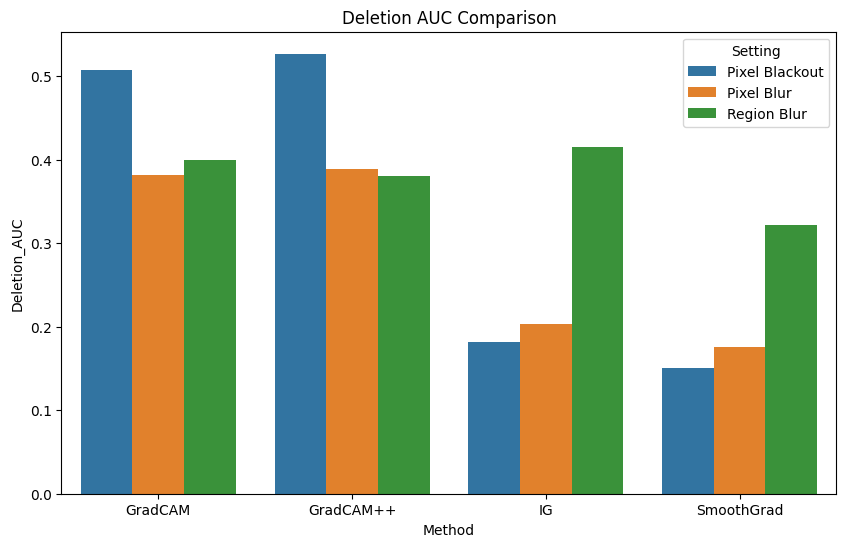

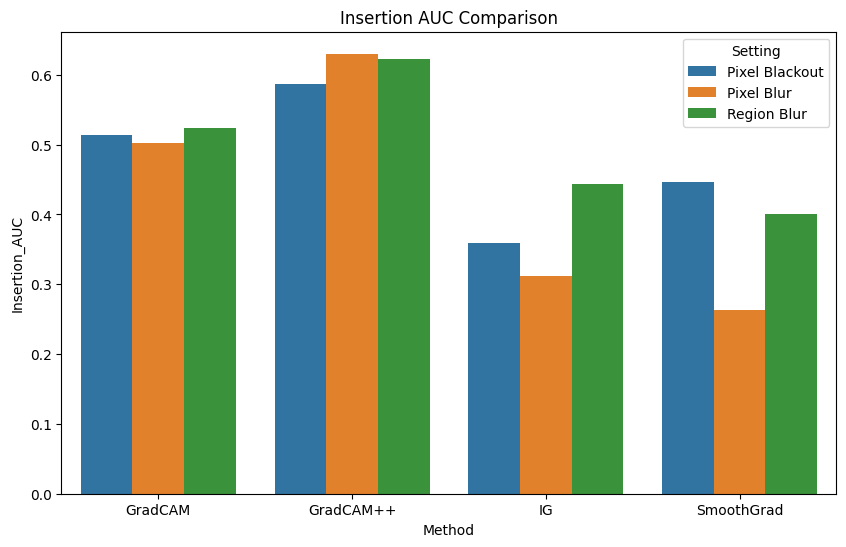

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=final_df, x="Method", y="Deletion_AUC", hue="Setting")
plt.title("Deletion AUC Comparison")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=final_df, x="Method", y="Insertion_AUC", hue="Setting")
plt.title("Insertion AUC Comparison")
plt.show()